<a href="https://colab.research.google.com/github/hkrishnanrt/DSA-Activities/blob/main/Classification_Activity_Harikrishnan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('/content/winequality-red.csv')
df=pd.DataFrame(data)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# Transformation

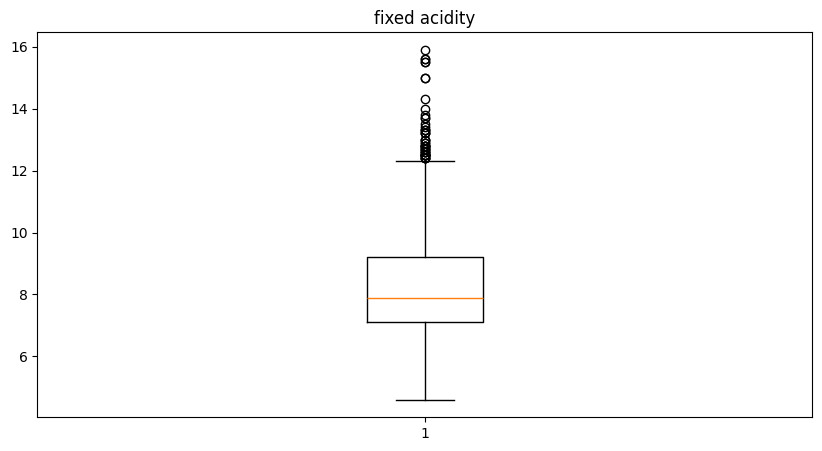

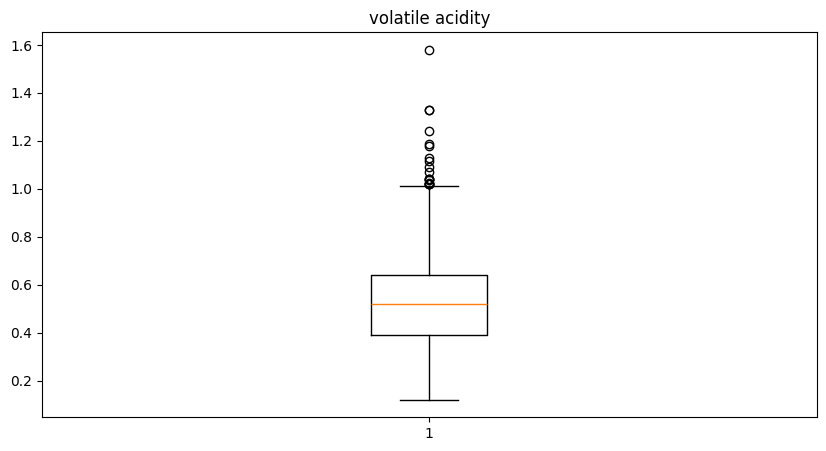

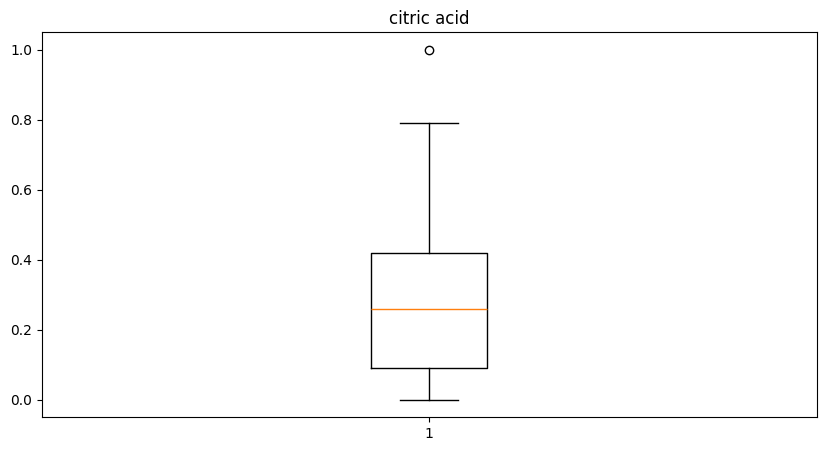

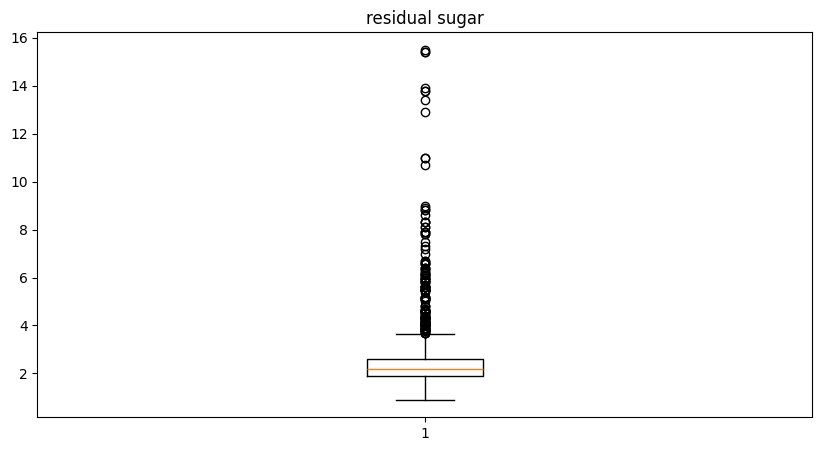

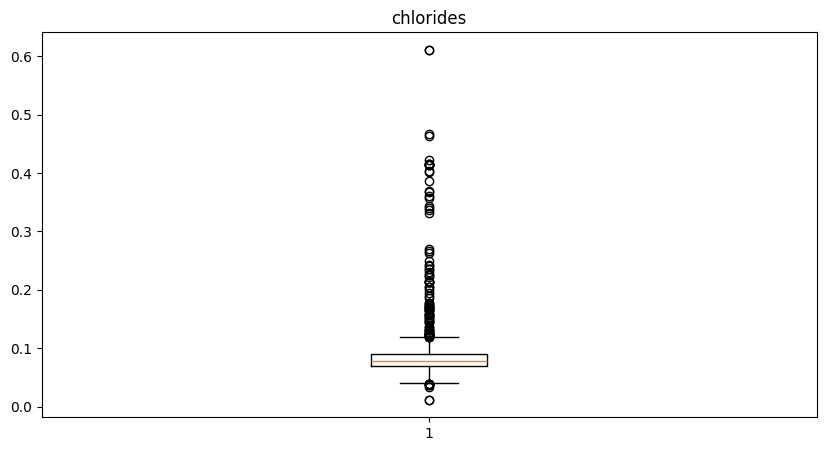

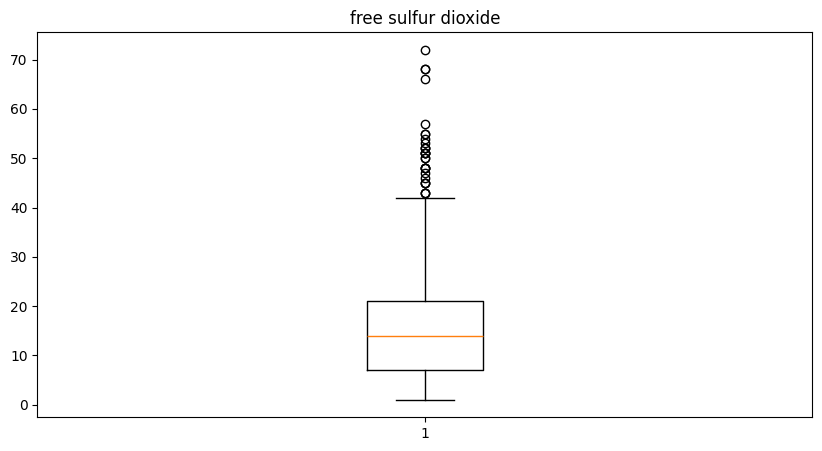

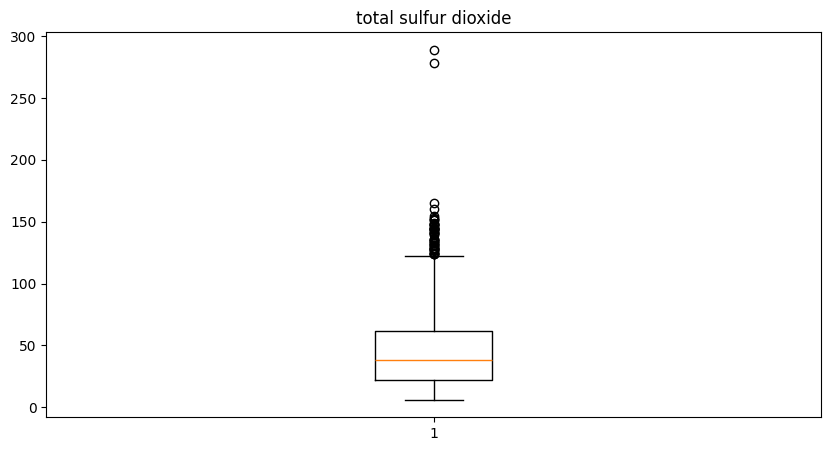

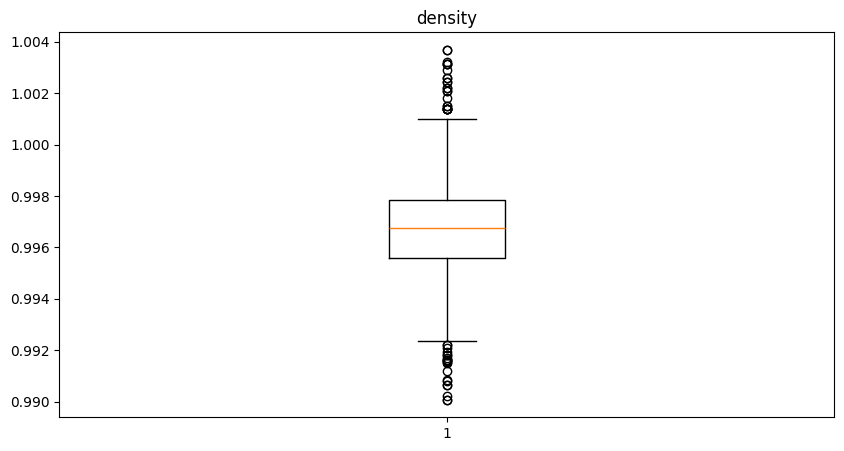

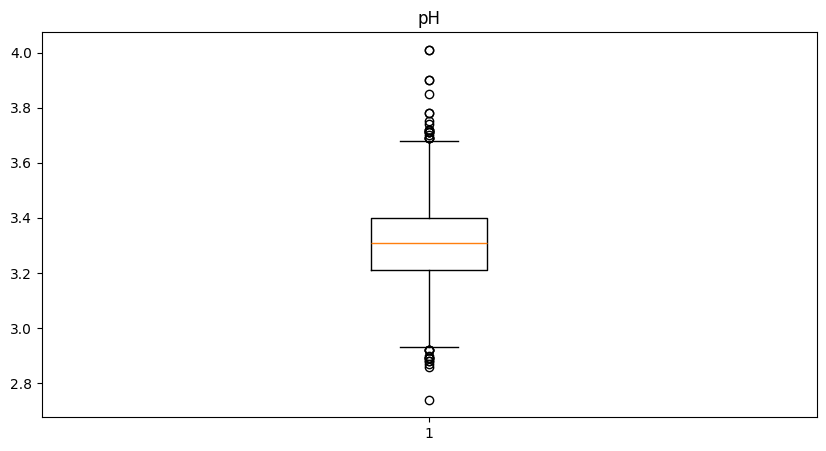

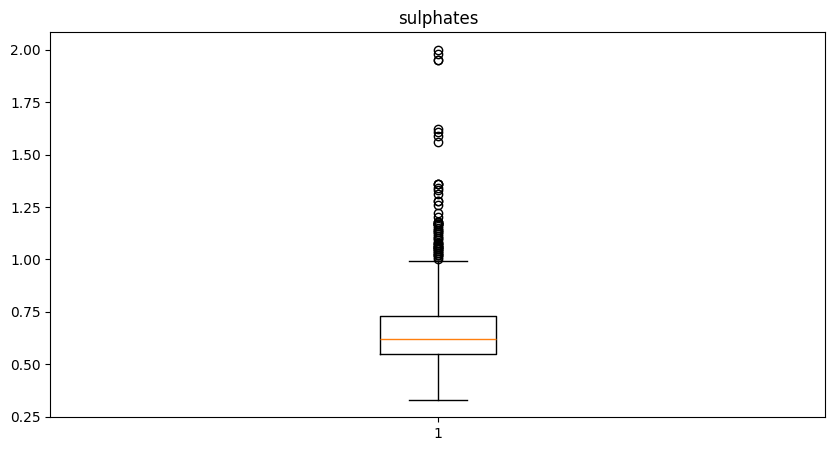

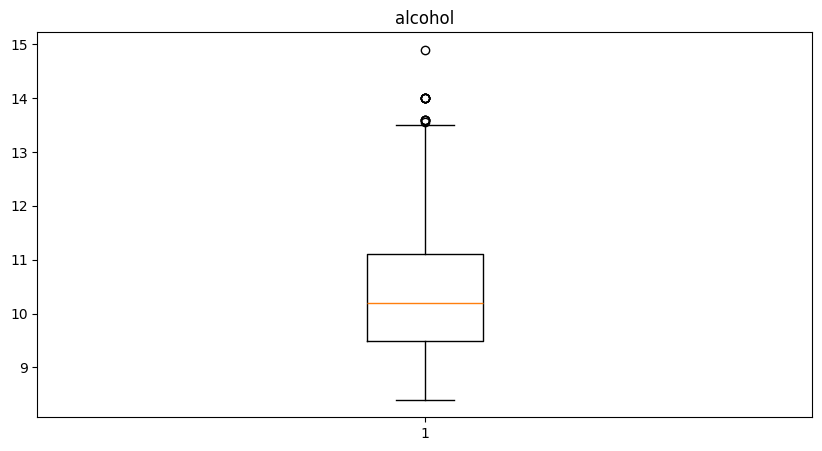

In [ ]:
num_cols=df.select_dtypes(include='float64')
for i in num_cols:
  plt.figure(figsize=(10,5))
  plt.boxplot(df[i])
  plt.title(i)

In [ ]:
log_cols=[
    'chlorides','sulphates','residual sugar','free sulfur dioxide','total sulfur dioxide'
]
for col in log_cols:
  df[col]=np.log1p(df[col])

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()

x=df.drop('quality',axis=1)
df[x.columns]=std_scaler.fit_transform(df[x.columns])

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.528360,0.961877,-1.391472,-0.568467,-0.251089,-0.247127,-0.116363,0.558274,1.288643,-0.601767,-0.960246,5
1,-0.298547,1.967442,-1.391472,0.232701,0.268164,0.992765,0.856963,0.028261,-0.719933,0.189123,-0.584777,5
2,-0.298547,1.297065,-1.186070,-0.089701,0.127588,0.214202,0.546021,0.134264,-0.331177,-0.003173,-0.584777,5
3,1.654856,-1.384443,1.484154,-0.568467,-0.274943,0.403079,0.697760,0.664277,-0.979104,-0.465815,-0.584777,6
4,-0.528360,0.961877,-1.391472,-0.568467,-0.251089,-0.247127,-0.116363,0.558274,1.288643,-0.601767,-0.960246,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.217796,0.403229,-0.980669,-0.442852,0.080558,1.375082,0.251938,-0.978765,0.899886,-0.465815,0.072294,5
1595,-1.390155,0.123905,-0.877968,-0.203719,-0.587080,1.683571,0.463822,-0.862162,1.353436,0.685591,0.729364,6
1596,-1.160343,-0.099554,-0.723916,-0.089701,-0.251089,1.222242,0.115514,-0.533554,0.705508,0.624781,0.541630,6
1597,-1.390155,0.654620,-0.775267,-0.442852,-0.274943,1.375082,0.251938,-0.676657,1.677400,0.378016,-0.209308,5


# Spliiting the Data

In [ ]:
X=df.drop(['quality'],axis=1)
y=df['quality']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

# Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
logit_model=LogisticRegression()
logit_model.fit(X_train,y_train)
y_pred=logit_model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
print('Accuracy is ',accuracy_score(y_test,y_pred))
print('Precision is ',precision_score(y_test,y_pred, average='weighted'))
print('Recall is ',recall_score(y_test,y_pred, average='weighted'))
print('f1 Score is ',f1_score(y_test,y_pred, average='weighted'))

Accuracy is  0.546875
Precision is  0.513635242910295
Recall is  0.546875
f1 Score is  0.52583907616849


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Knn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
metric_k=[]
neighbors=np.arange(3,15)

for k in neighbors:
  classifier=KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2)
  classifier.fit(X_train,y_train)
  y_pred=classifier.predict(X_test)
  acc=accuracy_score(y_test,y_pred)
  metric_k.append(acc)

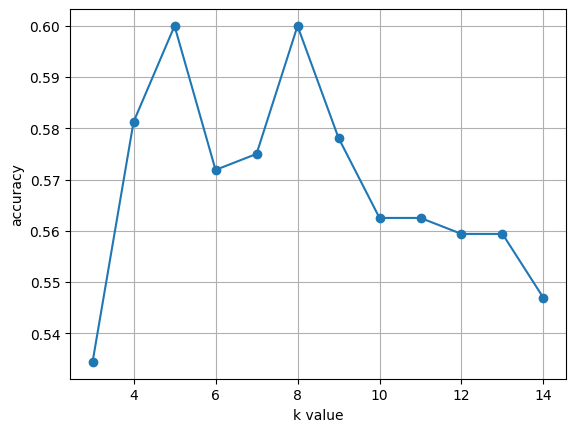

In [ ]:
plt.plot(neighbors,metric_k,'o-')
plt.xlabel('k value')
plt.ylabel('accuracy')
plt.grid()

In [ ]:
classifier=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
classifier.fit(X_train,y_train)
y_pred_knn=classifier.predict(X_test)


In [ ]:
print('Accuracy is ', accuracy_score(y_test,y_pred_knn))
print('Precision is ',precision_score(y_test,y_pred_knn, average='weighted'))
print('Recall is ',recall_score(y_test,y_pred_knn, average='weighted'))
print('f1 score is ',f1_score(y_test,y_pred_knn, average='weighted'))


Accuracy is  0.6
Precision is  0.5977966017488077
Recall is  0.6
f1 score is  0.5854619924712947


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
